In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from db import engine

plt.rcParams["figure.figsize"] = (15, 6)
sns.set_style('darkgrid')

In [2]:
with engine.connect() as conn:
    loc_df = pd.read_sql("select * from location", conn)
    weather_df = pd.read_sql("select * from weather_observation", conn)

In [3]:
weather_df.head()

,id,location_id,observed_at,temperature,feels_like,humidity,pressure,wind_speed,weather_description,weather_code,raw_json,created_at
0,7cc67643-b3cc-4dba-9a33-d7d3f86bd1b5,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-02 04:00:00+00:00,4.2,2.0,93.0,1001.0,4.2,None,3,None,2026-05-15 17:26:11.758867+00:00
1,ed70cecd-72f7-4fcc-a9f1-18e0533a5b66,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-02 05:00:00+00:00,4.2,1.9,93.0,1001.5,5.4,None,3,None,2026-05-15 17:26:11.758867+00:00
2,4b178fa5-df7b-481b-9a03-1242275c67d5,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-02 06:00:00+00:00,4.2,1.8,96.0,1001.7,6.5,None,51,None,2026-05-15 17:26:11.758867+00:00
3,d7977da2-6fb4-4df1-ad28-b86d57054e1a,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-02 07:00:00+00:00,4.4,2.2,96.0,1001.7,5.2,None,55,None,2026-05-15 17:26:11.758867+00:00
4,318e0712-f3e4-4964-89bc-da25576eed64,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-02 08:00:00+00:00,4.4,2.0,95.0,1001.8,6.4,None,51,None,2026-05-15 17:26:11.758867+00:00


In [4]:
def to_f(temp):
    return (temp * (9/5)) + 32

In [5]:
df = loc_df.merge(weather_df, left_on='id', right_on='location_id', suffixes=['_loc', '_wea'])

In [6]:
df['observed_date'] = df['observed_at'].dt.strftime('%Y-%m-%d')

In [7]:
df['month'] = df['observed_at'].dt.month_name()

In [8]:
df['temperature_f'] = df['temperature'].apply(to_f)
df['feels_like_f'] = df['feels_like'].apply(to_f)

In [58]:
df['day'] = df['observed_at'].dt.day

In [59]:
seattle = df[df['city'] == 'Seattle']

In [60]:
seattle.shape

(2880, 24)

In [63]:
seattle.head()

,id_loc,city,state,country,latitude,longitude,created_at_loc,id_wea,location_id,observed_at,...,wind_speed,weather_description,weather_code,raw_json,created_at_wea,observed_date,month,temperature_f,feels_like_f,day
0,20ac3297-5f99-4dc0-8383-0ad590b39c08,Seattle,WA,USA,47.6062,-122.3321,2026-05-15 17:26:10.280675+00:00,7cc67643-b3cc-4dba-9a33-d7d3f86bd1b5,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-02 04:00:00+00:00,...,4.2,None,3,None,2026-05-15 17:26:11.758867+00:00,2026-01-02,January,39.56,35.60,2
1,20ac3297-5f99-4dc0-8383-0ad590b39c08,Seattle,WA,USA,47.6062,-122.3321,2026-05-15 17:26:10.280675+00:00,ed70cecd-72f7-4fcc-a9f1-18e0533a5b66,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-02 05:00:00+00:00,...,5.4,None,3,None,2026-05-15 17:26:11.758867+00:00,2026-01-02,January,39.56,35.42,2
2,20ac3297-5f99-4dc0-8383-0ad590b39c08,Seattle,WA,USA,47.6062,-122.3321,2026-05-15 17:26:10.280675+00:00,4b178fa5-df7b-481b-9a03-1242275c67d5,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-02 06:00:00+00:00,...,6.5,None,51,None,2026-05-15 17:26:11.758867+00:00,2026-01-02,January,39.56,35.24,2
3,20ac3297-5f99-4dc0-8383-0ad590b39c08,Seattle,WA,USA,47.6062,-122.3321,2026-05-15 17:26:10.280675+00:00,d7977da2-6fb4-4df1-ad28-b86d57054e1a,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-02 07:00:00+00:00,...,5.2,None,55,None,2026-05-15 17:26:11.758867+00:00,2026-01-02,January,39.92,35.96,2
4,20ac3297-5f99-4dc0-8383-0ad590b39c08,Seattle,WA,USA,47.6062,-122.3321,2026-05-15 17:26:10.280675+00:00,318e0712-f3e4-4964-89bc-da25576eed64,20ac3297-5f99-4dc0-8383-0ad590b39c08,2026-01-02 08:00:00+00:00,...,6.4,None,51,None,2026-05-15 17:26:11.758867+00:00,2026-01-02,January,39.92,35.60,2


In [12]:
seattle.groupby("observed_date")[['temperature', 'feels_like']].mean()

,temperature,feels_like
observed_date,,
2026-01-01,2.495833,0.233333
2026-01-02,5.095833,3.208333
2026-01-03,8.145833,6.320833
2026-01-04,8.191667,5.745833
2026-01-05,5.829167,3.487500
...,...,...
2026-04-26,11.537500,9.012500
2026-04-27,11.679167,9.212500
2026-04-28,10.283333,8.095833


In [28]:
# sns.lineplot(data=seattle_jan, x='observed_at', y='temperature', label='Actual Temperature')
# sns.lineplot(data=seattle_jan, x='observed_at', y='feels_like', label='Feels Like')

## Basic Statistics for Seattle

In [39]:
def temperature_summary(df):
    min_temp = df['temperature_f'].min()
    max_temp = df['temperature_f'].max()
    avg_temp = df['temperature_f'].mean().round(2)
    median_temp = df['temperature_f'].median().round(2)

    return f"""
    Minimum Temperature: {min_temp}
    Maximum Temperature: {max_temp}
    Average Temperature: {avg_temp}
    Median Temperature: {median_temp}
    """

In [57]:
print(temperature_summary(seattle))


    Minimum Temperature: 25.88
    Maximum Temperature: 73.22
    Average Temperature: 45.01
    Median Temperature: 44.96
    


In [61]:
day_month_temp = pd.pivot_table(data=seattle, columns='month', index='day', values='temperature_f')[['January', 'February', 'March', 'April']]

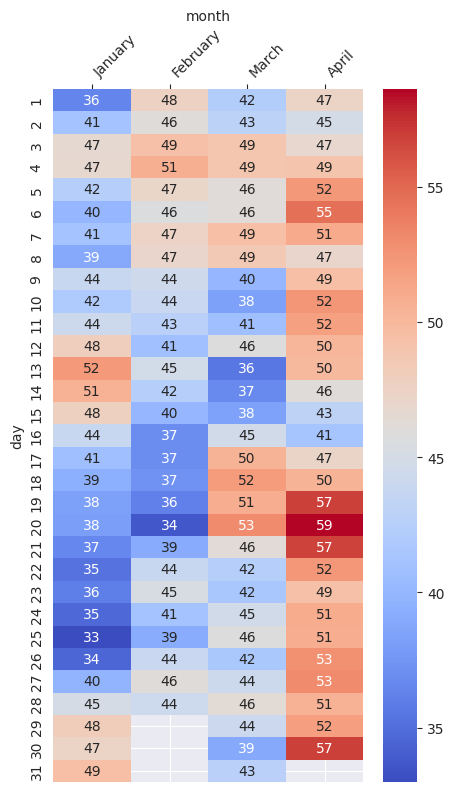

In [62]:
plt.figure(figsize=(5, 9))
ax = sns.heatmap(data=day_month_temp, cmap='coolwarm', annot=True)
ax.xaxis.tick_top()
ax.xaxis.set_label_position("top")

plt.xticks(rotation=45, ha="left");

## Seattle Analysis in January

In [66]:
seattle_jan = seattle[seattle['month'] == 'January']

In [67]:
seattle_jan_group = seattle_jan.groupby(['observed_date'])[['temperature', 'temperature_f', 'feels_like', 'feels_like_f', 'wind_speed']].mean().reset_index()

In [68]:
seattle_jan_group['diff_t'] = seattle_jan_group['temperature_f'] - seattle_jan_group['feels_like_f']
seattle_jan_group['diff'] = seattle_jan_group['temperature'] - seattle_jan_group['feels_like']

In [69]:
seattle_jan_group['observed_date'] = pd.to_datetime(seattle_jan_group['observed_date'])

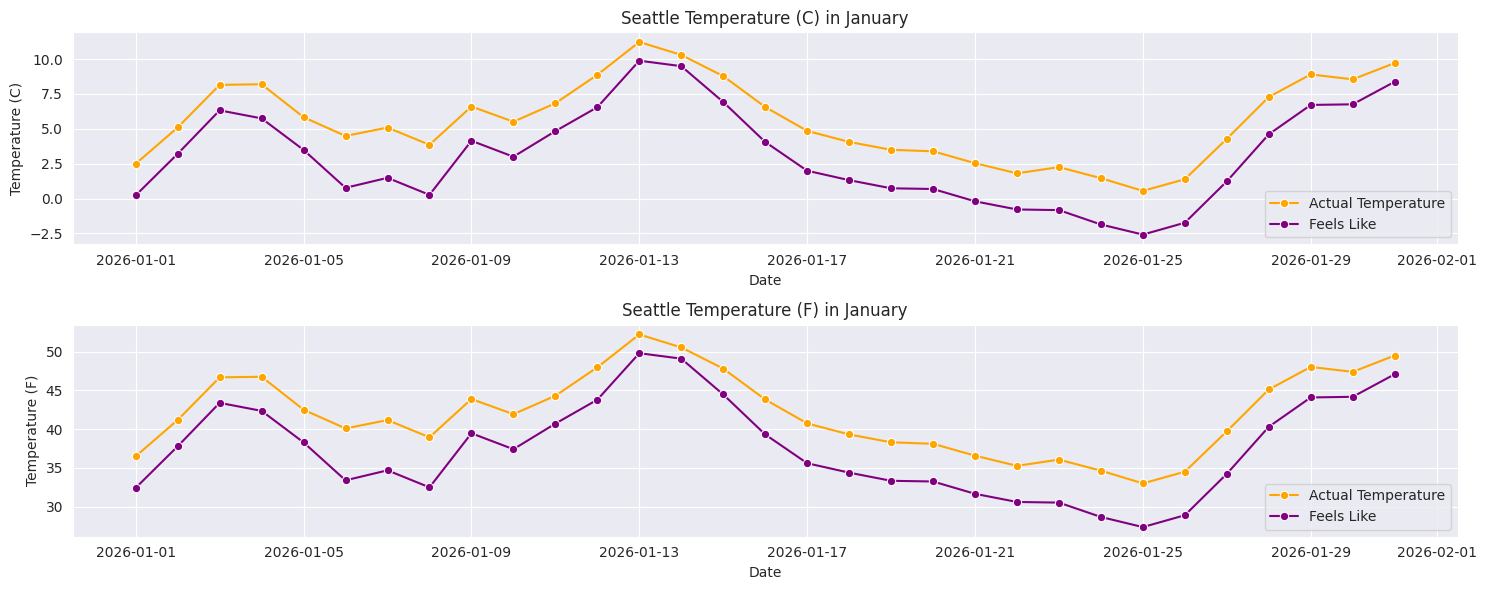

In [70]:
fig, ax = plt.subplots(2, 1)
sns.lineplot(data=seattle_jan_group, x='observed_date', y='temperature', label='Actual Temperature', marker='o', ax=ax[0], color='orange')
sns.lineplot(data=seattle_jan_group, x='observed_date', y='feels_like', label='Feels Like', marker='o', ax=ax[0], color='purple')

ax[0].set_title("Seattle Temperature (C) in January")
ax[0].set_xlabel("Date")
ax[0].set_ylabel("Temperature (C)")

sns.lineplot(data=seattle_jan_group, x='observed_date', y='temperature_f', label='Actual Temperature', marker='o', ax=ax[1], color='orange')
sns.lineplot(data=seattle_jan_group, x='observed_date', y='feels_like_f', label='Feels Like', marker='o', ax=ax[1] , color='purple')

ax[1].set_title("Seattle Temperature (F) in January")
ax[1].set_xlabel("Date")
ax[1].set_ylabel("Temperature (F)")

plt.tight_layout()